# Notebook 1 — Text NLP Pipeline

**Run this notebook from:** `notebooks\`

**Input:** `..\data\raw\text\Cyberbullying.csv`

**Outputs saved to** `notebooks\data\processed\`:
- `phase1_labeled_text.csv`
- `phase2_cleaned_text.csv`
- `phase3_nlp_results.csv`
- `phase3_with_severity.csv` ← used by Notebook 3

---
Run cells **one at a time**. Each cell prints `✅` when it succeeds.

In [1]:
# ── CELL 1 — Imports & Path Check ──────────────────────────────────────────
import pandas as pd
import numpy as np
import re
import nltk
import spacy
from pathlib import Path
from tqdm import tqdm
from transformers import pipeline
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

# Paths — relative to notebooks\ folder
RAW_CSV   = Path('..') / 'data' / 'raw' / 'text' / 'Cyberbullying.csv'
PROCESSED = Path('data') / 'processed'
PROCESSED.mkdir(parents=True, exist_ok=True)

print('✅ Cell 1 OK')
print(f'   RAW_CSV   : {RAW_CSV.resolve()}')
print(f'   PROCESSED : {PROCESSED.resolve()}')
print(f'   CSV found : {RAW_CSV.exists()}')

✅ Cell 1 OK
   RAW_CSV   : C:\Users\tejas\Major_Project\AI_Digital_Evidence_Extraction\data\raw\text\Cyberbullying.csv
   PROCESSED : C:\Users\tejas\Major_Project\AI_Digital_Evidence_Extraction\notebooks\data\processed
   CSV found : True


In [2]:
# ── CELL 2 — Load Dataset ──────────────────────────────────────────────────
assert RAW_CSV.exists(), (
    f'\n❌ File not found: {RAW_CSV.resolve()}'
    f'\n   Make sure Cyberbullying.csv is in data\\raw\\text\\'
)

df = pd.read_csv(RAW_CSV)

print(f'✅ Cell 2 OK — {len(df):,} rows loaded')
print(f'   Columns: {list(df.columns)}')
df.head()

✅ Cell 2 OK — 47,692 rows loaded
   Columns: ['tweet_text', 'cyberbullying_type']


,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


In [3]:
# ── CELL 3 — Label & Save Phase 1 ─────────────────────────────────────────
df.rename(columns={'tweet_text': 'text'}, inplace=True)

df['label'] = df['cyberbullying_type'].apply(
    lambda x: 'normal' if x == 'not_cyberbullying' else 'harmful'
)

df = df[['text', 'label']].dropna(subset=['text']).reset_index(drop=True)

out = PROCESSED / 'phase1_labeled_text.csv'
df.to_csv(out, index=False)

print(f'✅ Cell 3 OK — saved to {out.name}')
print(df['label'].value_counts())

✅ Cell 3 OK — saved to phase1_labeled_text.csv
label
harmful    39747
normal      7945
Name: count, dtype: int64


In [4]:
# ── CELL 4 — Text Preprocessing & Save Phase 2 ────────────────────────────
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)         # remove mentions & hashtags
    text = re.sub(r'[^a-z\s]', '', text)           # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()        # collapse spaces
    text = ' '.join(w for w in text.split() if w not in stop_words)
    return text

df['clean_text'] = df['text'].apply(clean_text)
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)

out = PROCESSED / 'phase2_cleaned_text.csv'
df.to_csv(out, index=False)

print(f'✅ Cell 4 OK — saved to {out.name}')
print(f'   Rows after cleaning: {len(df):,}')
df.head()

✅ Cell 4 OK — saved to phase2_cleaned_text.csv
   Rows after cleaning: 47,215


,text,label,clean_text
0,"In other words #katandandre, your food was cra...",normal,words food crapilicious
1,Why is #aussietv so white? #MKR #theblock #ImA...,normal,white
2,@XochitlSuckkks a classy whore? Or more red ve...,normal,classy whore red velvet cupcakes
3,"@Jason_Gio meh. :P thanks for the heads up, b...",normal,meh p thanks heads concerned another angry dud...
4,@RudhoeEnglish This is an ISIS account pretend...,normal,isis account pretending kurdish account like i...


In [5]:
# ── CELL 5 — Load Models ───────────────────────────────────────────────────
#
# unitary/toxic-bert   → stores weights in safetensors format
#                        works on torch 2.5.x without any upgrade needed
# distilbert SST-2     → already safetensors, no issues
# spaCy en_core_web_sm → no torch dependency

nlp = spacy.load('en_core_web_sm', disable=['tagger', 'parser', 'lemmatizer'])
print('   spaCy         : loaded')

toxicity_classifier = pipeline(
    'text-classification',
    model='unitary/toxic-bert',
    truncation=True,
    max_length=512
)
print('   toxic-bert     : loaded')

sentiment_analyzer = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    truncation=True,
    max_length=512
)
print('   distilbert SST : loaded')

print('\n✅ Cell 5 OK — all 3 models ready')

   spaCy         : loaded


Device set to use cpu


   toxic-bert     : loaded


Device set to use cpu


   distilbert SST : loaded

✅ Cell 5 OK — all 3 models ready


In [6]:
# ── CELL 6 — NLP Analysis on Harmful Texts Only ───────────────────────────
#
# We only run NER + toxicity + sentiment on rows labelled 'harmful'
# Normal rows keep None — saves significant processing time

mask          = df['label'] == 'harmful'
harmful_texts = df.loc[mask, 'clean_text'].tolist()
harmful_idx   = df.index[mask].tolist()

print(f'Harmful rows to process: {len(harmful_texts):,}')

# Step 1 — NER
print('\n  Step 1/3 — Named Entity Recognition...')
entities = []
for doc in tqdm(nlp.pipe(harmful_texts, batch_size=64),
                total=len(harmful_texts), desc='NER'):
    entities.append(str([(ent.text, ent.label_) for ent in doc.ents]))

# Step 2 — Toxicity
print('\n  Step 2/3 — Toxicity scoring...')
tox_results = toxicity_classifier(harmful_texts, batch_size=32, truncation=True)
tox_labels  = [r['label'] for r in tox_results]
tox_scores  = [round(r['score'], 4) for r in tox_results]

# Step 3 — Sentiment
print('\n  Step 3/3 — Sentiment analysis...')
sent_results = sentiment_analyzer(harmful_texts, batch_size=32, truncation=True)
sentiments   = [r['label'] for r in sent_results]

print('\n✅ Cell 6 OK — NLP analysis complete')

Harmful rows to process: 39,441

  Step 1/3 — Named Entity Recognition...


NER: 100%|██████████████████████████████████████████████████████████████████████| 39441/39441 [02:08<00:00, 305.88it/s]



  Step 2/3 — Toxicity scoring...

  Step 3/3 — Sentiment analysis...

✅ Cell 6 OK — NLP analysis complete


In [7]:
# ── CELL 7 — Assign Results & Save Phase 3 ────────────────────────────────
df['named_entities'] = None
df['toxicity_label'] = None
df['toxicity_score'] = None
df['sentiment']      = None

df.loc[harmful_idx, 'named_entities'] = entities
df.loc[harmful_idx, 'toxicity_label'] = tox_labels
df.loc[harmful_idx, 'toxicity_score'] = tox_scores
df.loc[harmful_idx, 'sentiment']      = sentiments

df.to_json(PROCESSED / 'phase3_nlp_results.json', orient='records', lines=True)
df.to_csv(PROCESSED  / 'phase3_nlp_results.csv',  index=False)

print('✅ Cell 7 OK — phase3_nlp_results saved')
print(f'   Rows with toxicity score: {df["toxicity_score"].notna().sum():,}')
df[df['label'] == 'harmful'][
    ['text', 'toxicity_label', 'toxicity_score', 'sentiment']
].head()

✅ Cell 7 OK — phase3_nlp_results saved
   Rows with toxicity score: 39,441


,text,toxicity_label,toxicity_score,sentiment
7774,rape is real..zvasiyana nema jokes about being...,toxic,0.9798,NEGATIVE
7775,You never saw any celebrity say anything like ...,toxic,0.7574,NEGATIVE
7776,"@ManhattaKnight I mean he's gay, but he uses g...",toxic,0.8997,NEGATIVE
7777,RT @Raul_Novoa16: @AliciaBernardez @Alex_Aim @...,toxic,0.005,POSITIVE
7778,Rape is rape. And the fact that I read one pos...,toxic,0.9011,NEGATIVE


In [8]:
# ── CELL 8 — Severity Scoring & Final Save ────────────────────────────────
#
# toxic-bert labels:  'toxic' or 'neutral'
# Severity scale:  0 = Low | 1 = Moderate | 2 = High | 3 = Critical

def compute_severity(row):
    if row['label'] == 'normal' or pd.isna(row['toxicity_score']):
        return 0
    if str(row['toxicity_label']).lower() != 'toxic':
        return 0
    score = float(row['toxicity_score'])
    if score >= 0.90: return 3  # Critical
    if score >= 0.75: return 2  # High
    if score >= 0.50: return 1  # Moderate
    return 0                    # Low

df['severity_score'] = df.apply(compute_severity, axis=1)

out = PROCESSED / 'phase3_with_severity.csv'
df.to_csv(out, index=False)

print(f'✅ Cell 8 OK — saved to {out.name}')
print('\nSeverity breakdown:')
print(
    df['severity_score'].value_counts().sort_index()
    .rename({0: '0 — Low', 1: '1 — Moderate', 2: '2 — High', 3: '3 — Critical'})
)

✅ Cell 8 OK — saved to phase3_with_severity.csv

Severity breakdown:
severity_score
0 — Low         24123
1 — Moderate     3850
2 — High         4452
3 — Critical    14790
Name: count, dtype: int64


Running toxic-bert on ALL rows for proper evaluation...
(This includes normal rows — needed for real accuracy measurement)
       MODEL EVALUATION METRICS
  Accuracy  : 83.53%
  Precision : 83.54%
  Recall    : 99.99%
  F1 Score  : 91.03%

Detailed Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.25      0.00      0.00      7774
 Harmful (1)       0.84      1.00      0.91     39441

    accuracy                           0.84     47215
   macro avg       0.54      0.50      0.46     47215
weighted avg       0.74      0.84      0.76     47215



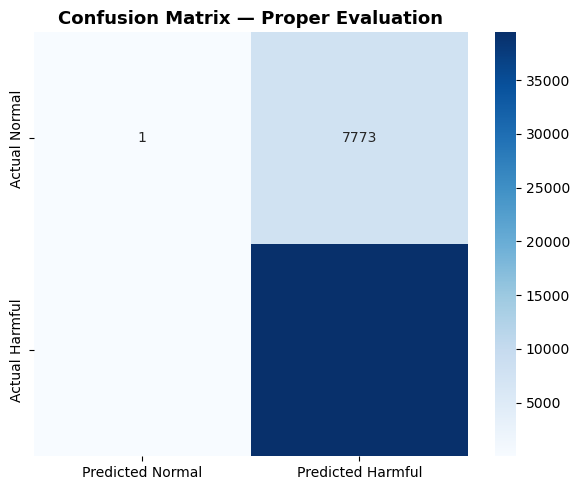

✅ Cell 9 OK


In [10]:
# ── CELL 9 — Proper Model Evaluation ──────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

print('Running toxic-bert on ALL rows for proper evaluation...')
print('(This includes normal rows — needed for real accuracy measurement)')

all_texts  = df['clean_text'].tolist()
all_idx    = df.index.tolist()

# Run model on everything
all_results = toxicity_classifier(all_texts, batch_size=32, truncation=True)
df['eval_label'] = [
    'harmful' if r['label'].lower() == 'toxic' else 'normal'
    for r in all_results
]

# Compare against ground truth
y_true = (df['label']      == 'harmful').astype(int)
y_pred = (df['eval_label'] == 'harmful').astype(int)

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall    = recall_score(y_true, y_pred, zero_division=0)
f1        = f1_score(y_true, y_pred, zero_division=0)
cm        = confusion_matrix(y_true, y_pred)

print('=' * 45)
print('       MODEL EVALUATION METRICS')
print('=' * 45)
print(f'  Accuracy  : {accuracy  * 100:.2f}%')
print(f'  Precision : {precision * 100:.2f}%')
print(f'  Recall    : {recall    * 100:.2f}%')
print(f'  F1 Score  : {f1        * 100:.2f}%')
print('=' * 45)
print('\nDetailed Classification Report:')
print(classification_report(y_true, y_pred,
      target_names=['Normal (0)', 'Harmful (1)']))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted Normal', 'Predicted Harmful'],
    yticklabels=['Actual Normal',    'Actual Harmful'], ax=ax)
ax.set_title('Confusion Matrix — Proper Evaluation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

df.to_csv(PROCESSED / 'phase3_with_severity.csv', index=False)
print('✅ Cell 9 OK')